<a href="https://colab.research.google.com/github/Rajarathour17/AI-Driven-Archeaological-Site-Mapping/blob/main/Soil_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!pip install ultralytics

In [18]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.214 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.6/112.6 GB disk)


In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
ROOT_DIR = '/content/drive/MyDrive/Soil_detection.v2i.yolov11'

In [22]:
from ultralytics import YOLO

# Load a dataset YOLO11n model
model = YOLO("yolo11n.pt")

# Train the model
results = model.train(data="/content/drive/MyDrive/Soil_detection.v2i.yolov11/data.yaml", epochs=100, imgsz=640)

Ultralytics 8.3.214 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Soil_detection.v2i.yolov11/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pe

In [1]:
!ls '/content/runs/detect/train3'

ls: cannot access '/content/runs/detect/train4': No such file or directory


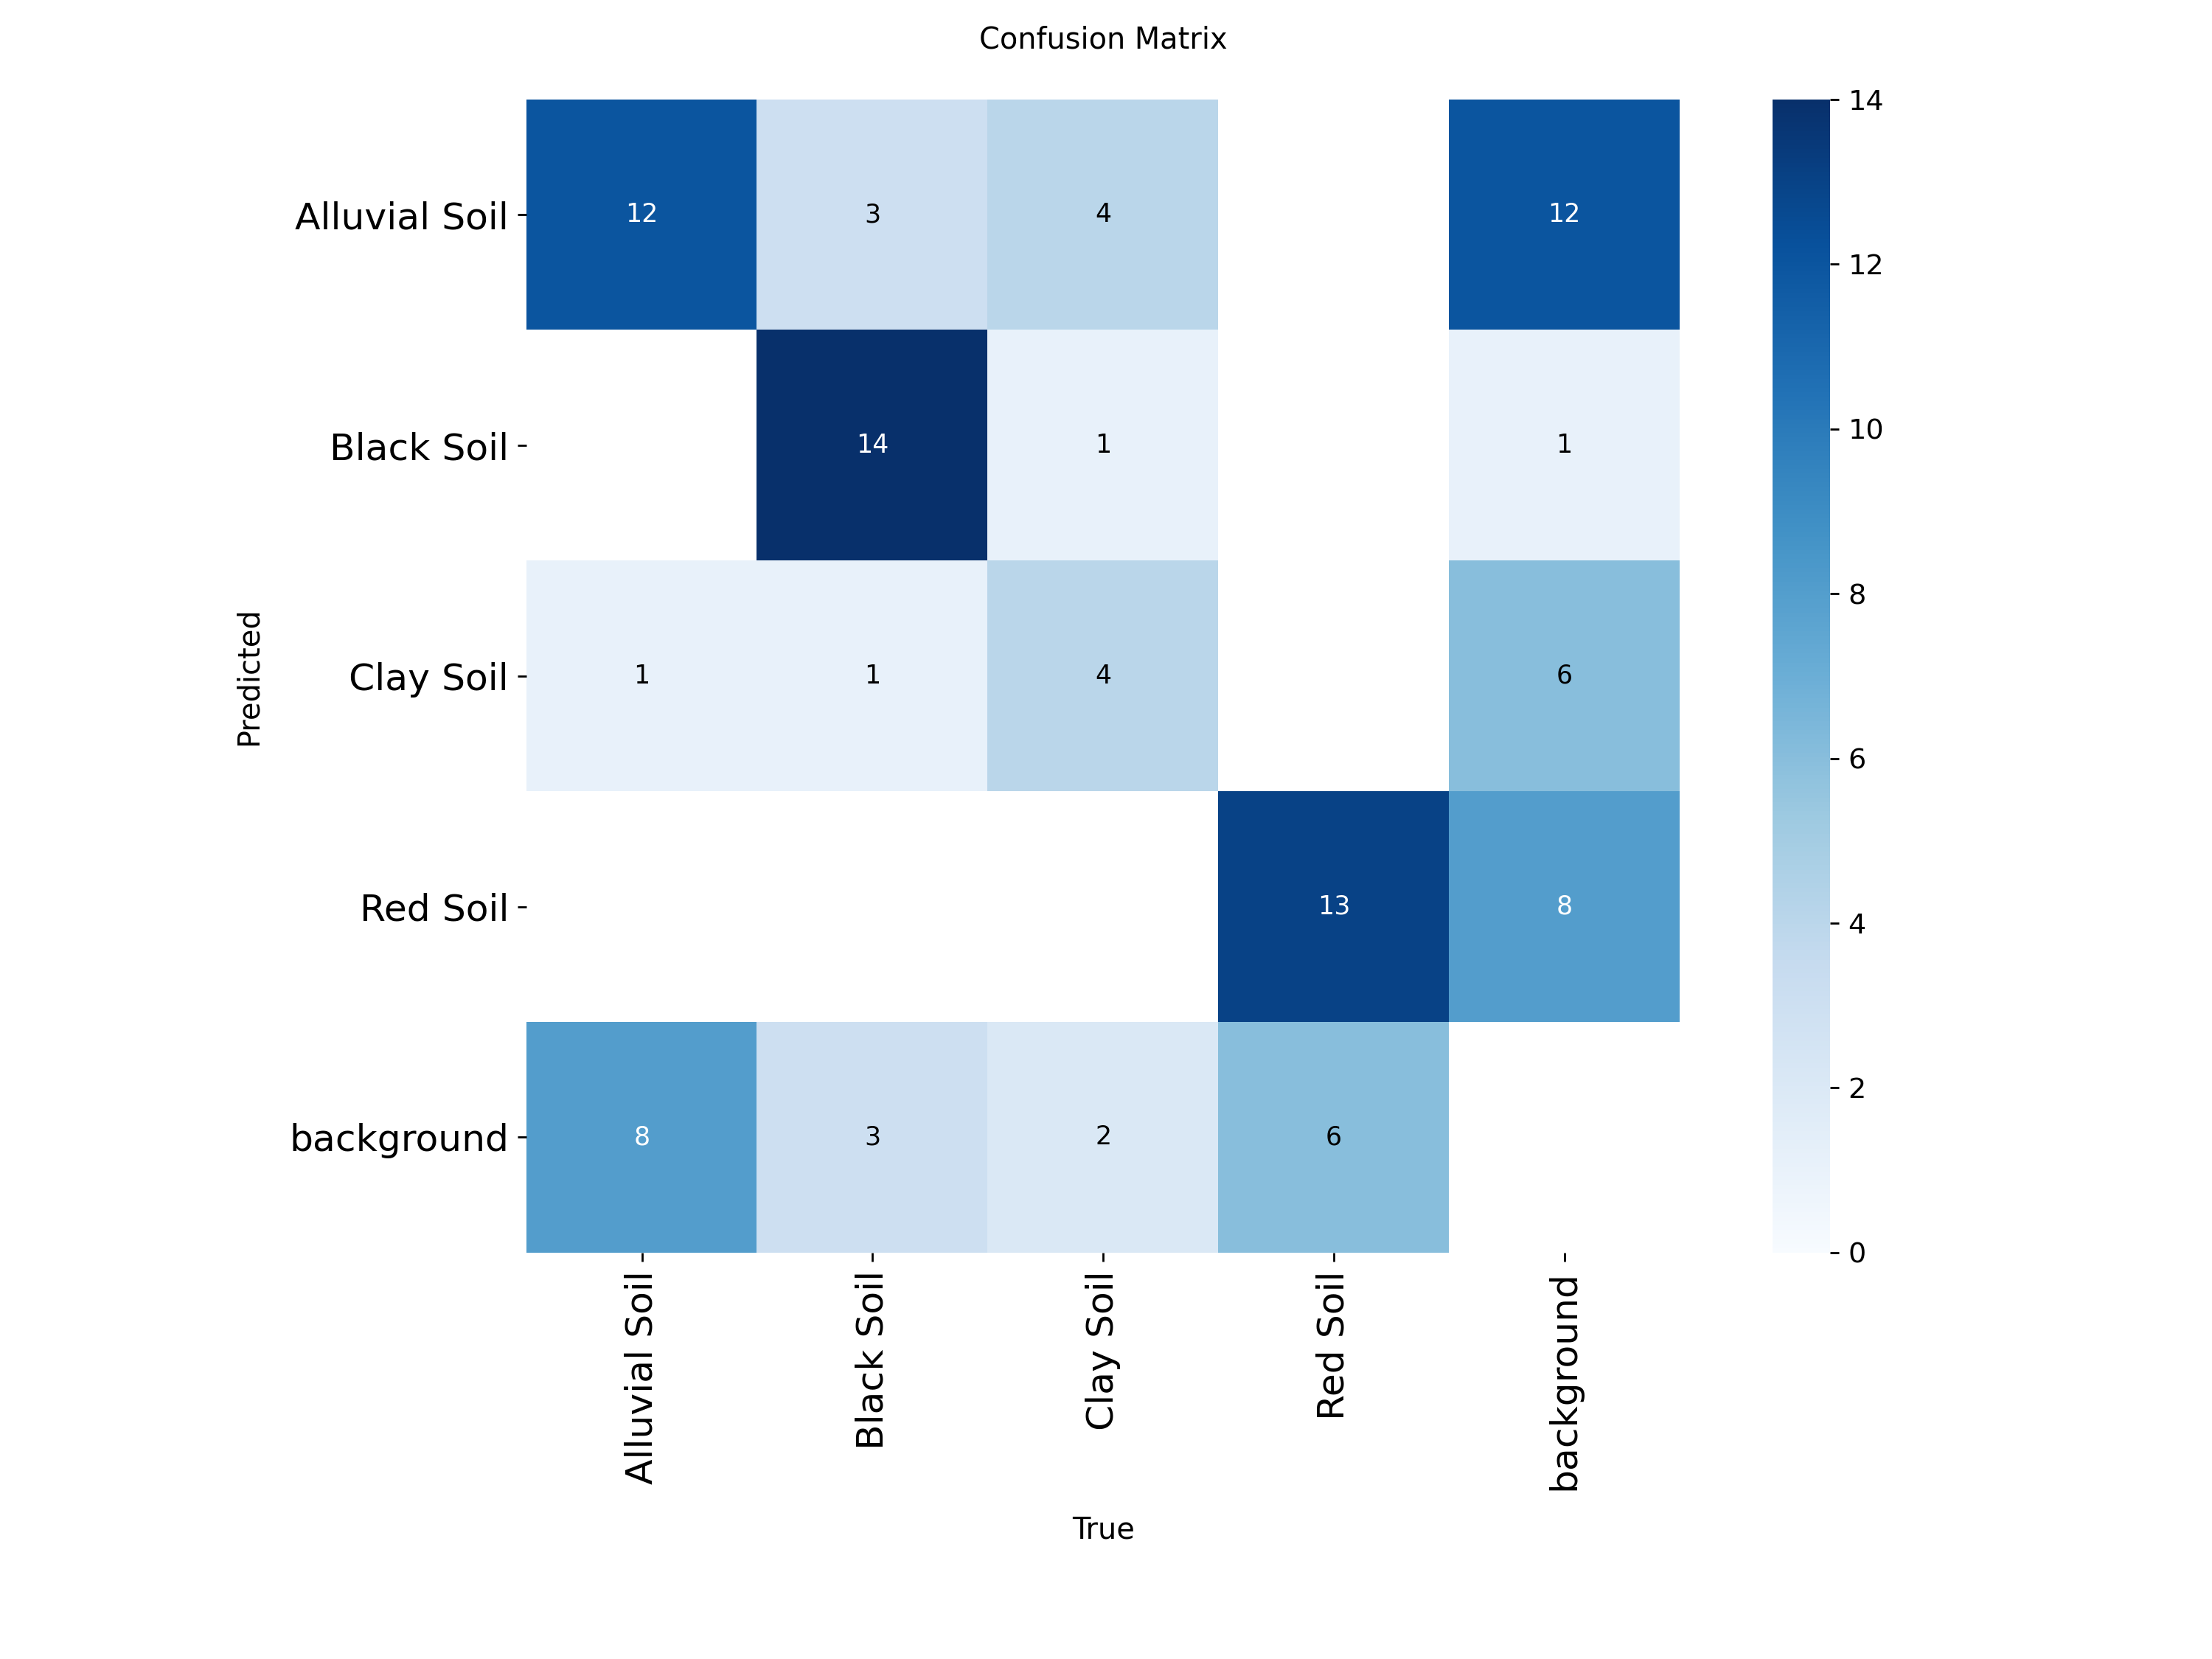

In [11]:
resultData = '/content/runs/detect/train3'
from IPython.display import Image, display

Image(filename=f'{resultData}/confusion_matrix.png')

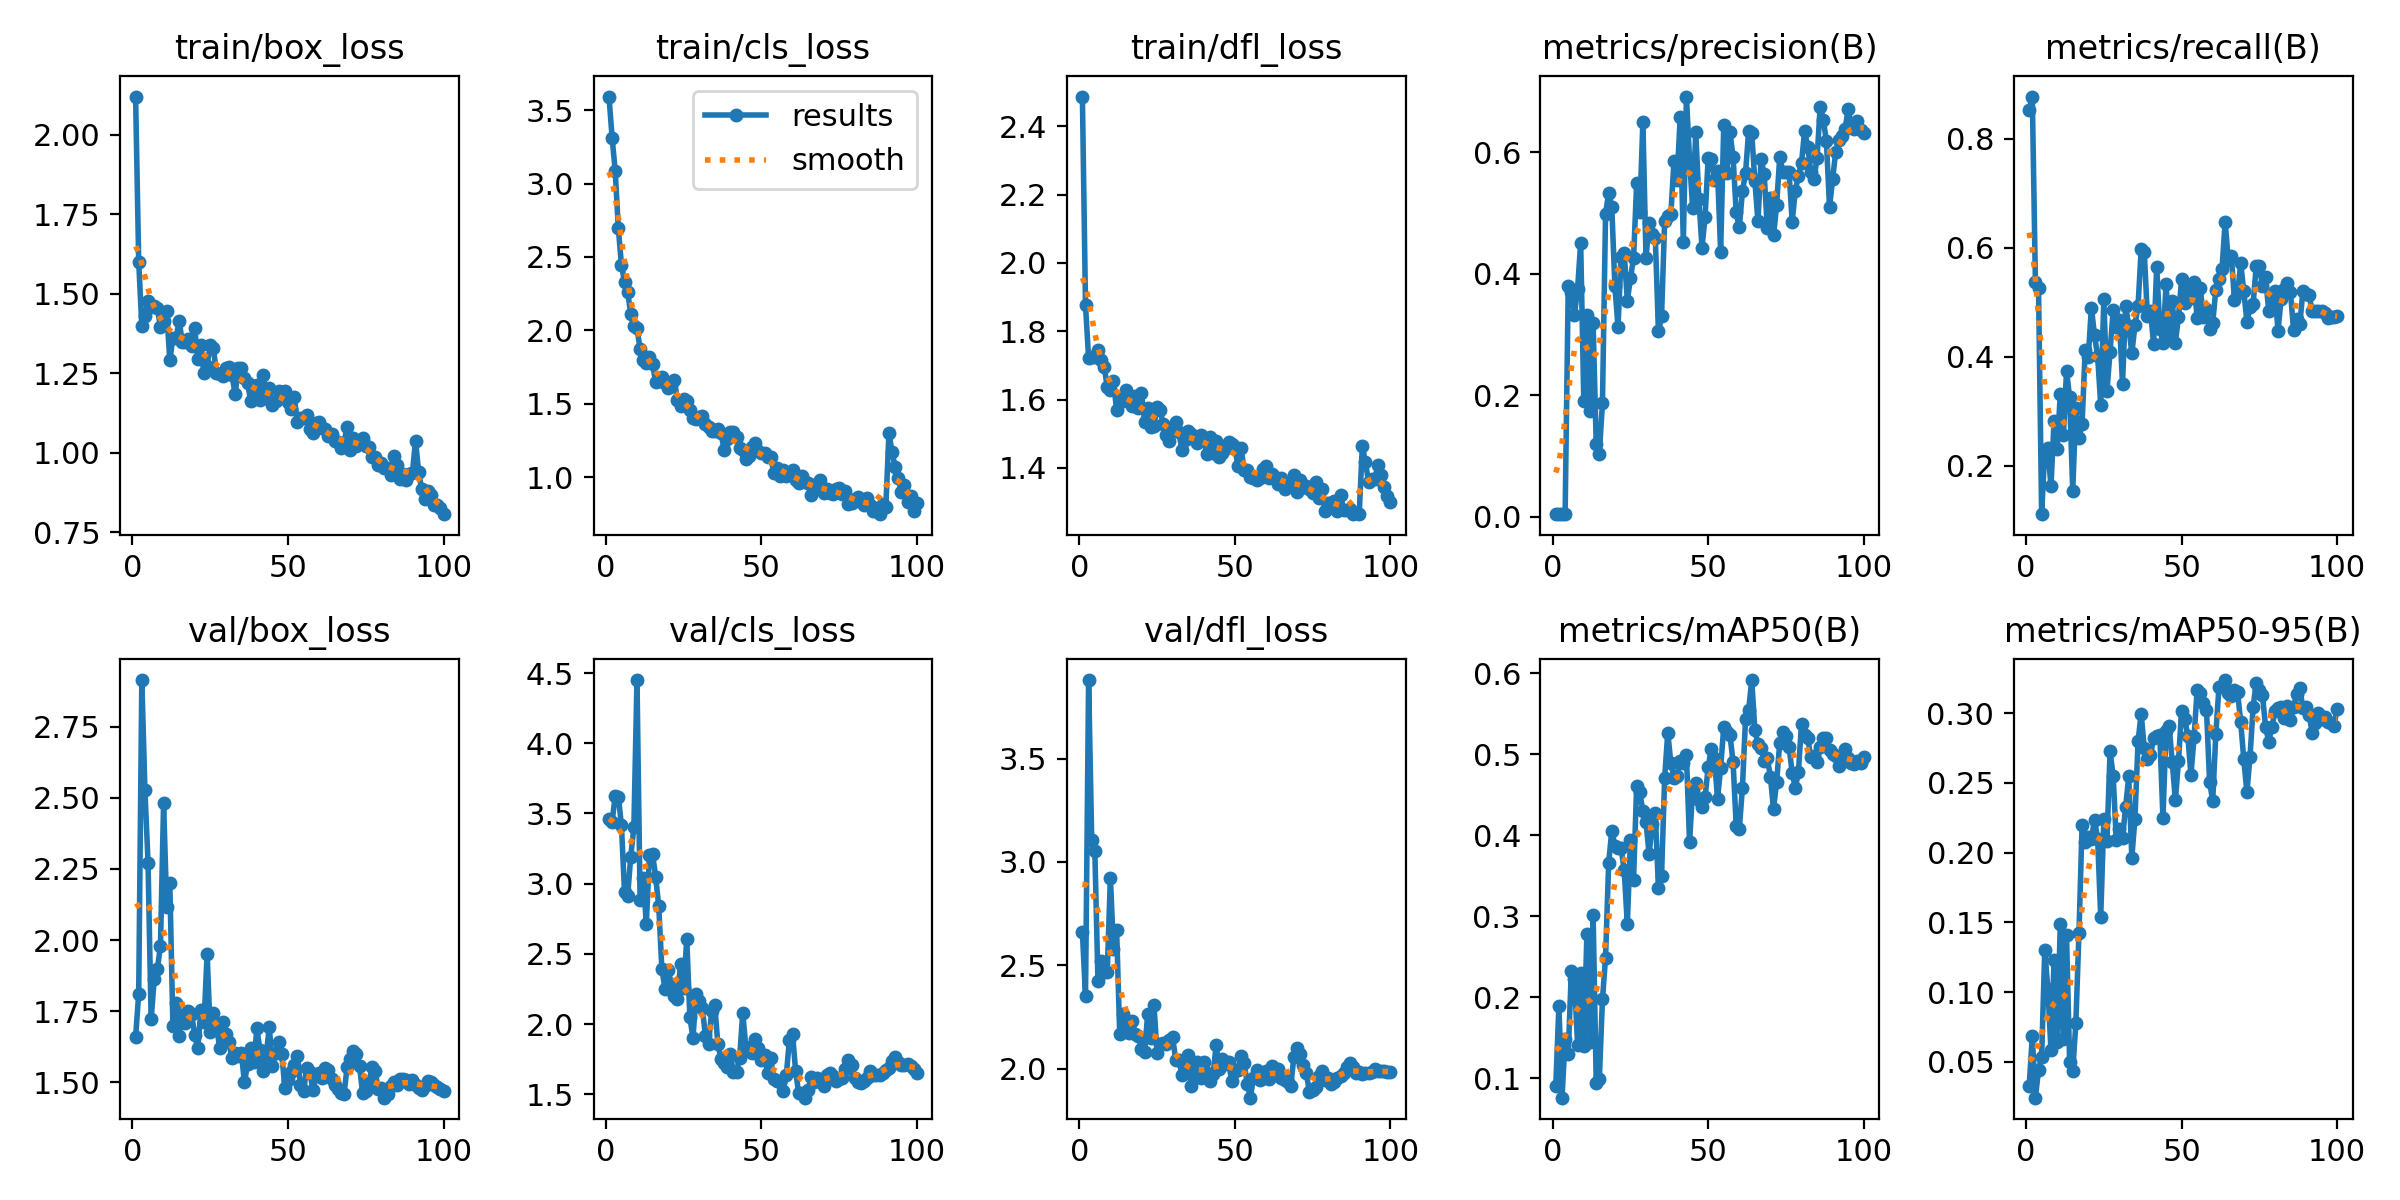

In [12]:
from IPython.display import Image, display
Image(filename=f'{resultData}/results.png')

In [13]:
import pandas as pd
df =pd.read_csv(f'{resultData}/results.csv') #df = dataframe
print (df.tail(1))

    epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
99    100  474.417         0.80654         0.82167         1.30005   

    metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
99               0.63137            0.47374           0.49714   

    metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
99              0.30328       1.46801       1.65482       1.98252  0.000025   

      lr/pg1    lr/pg2  
99  0.000025  0.000025  


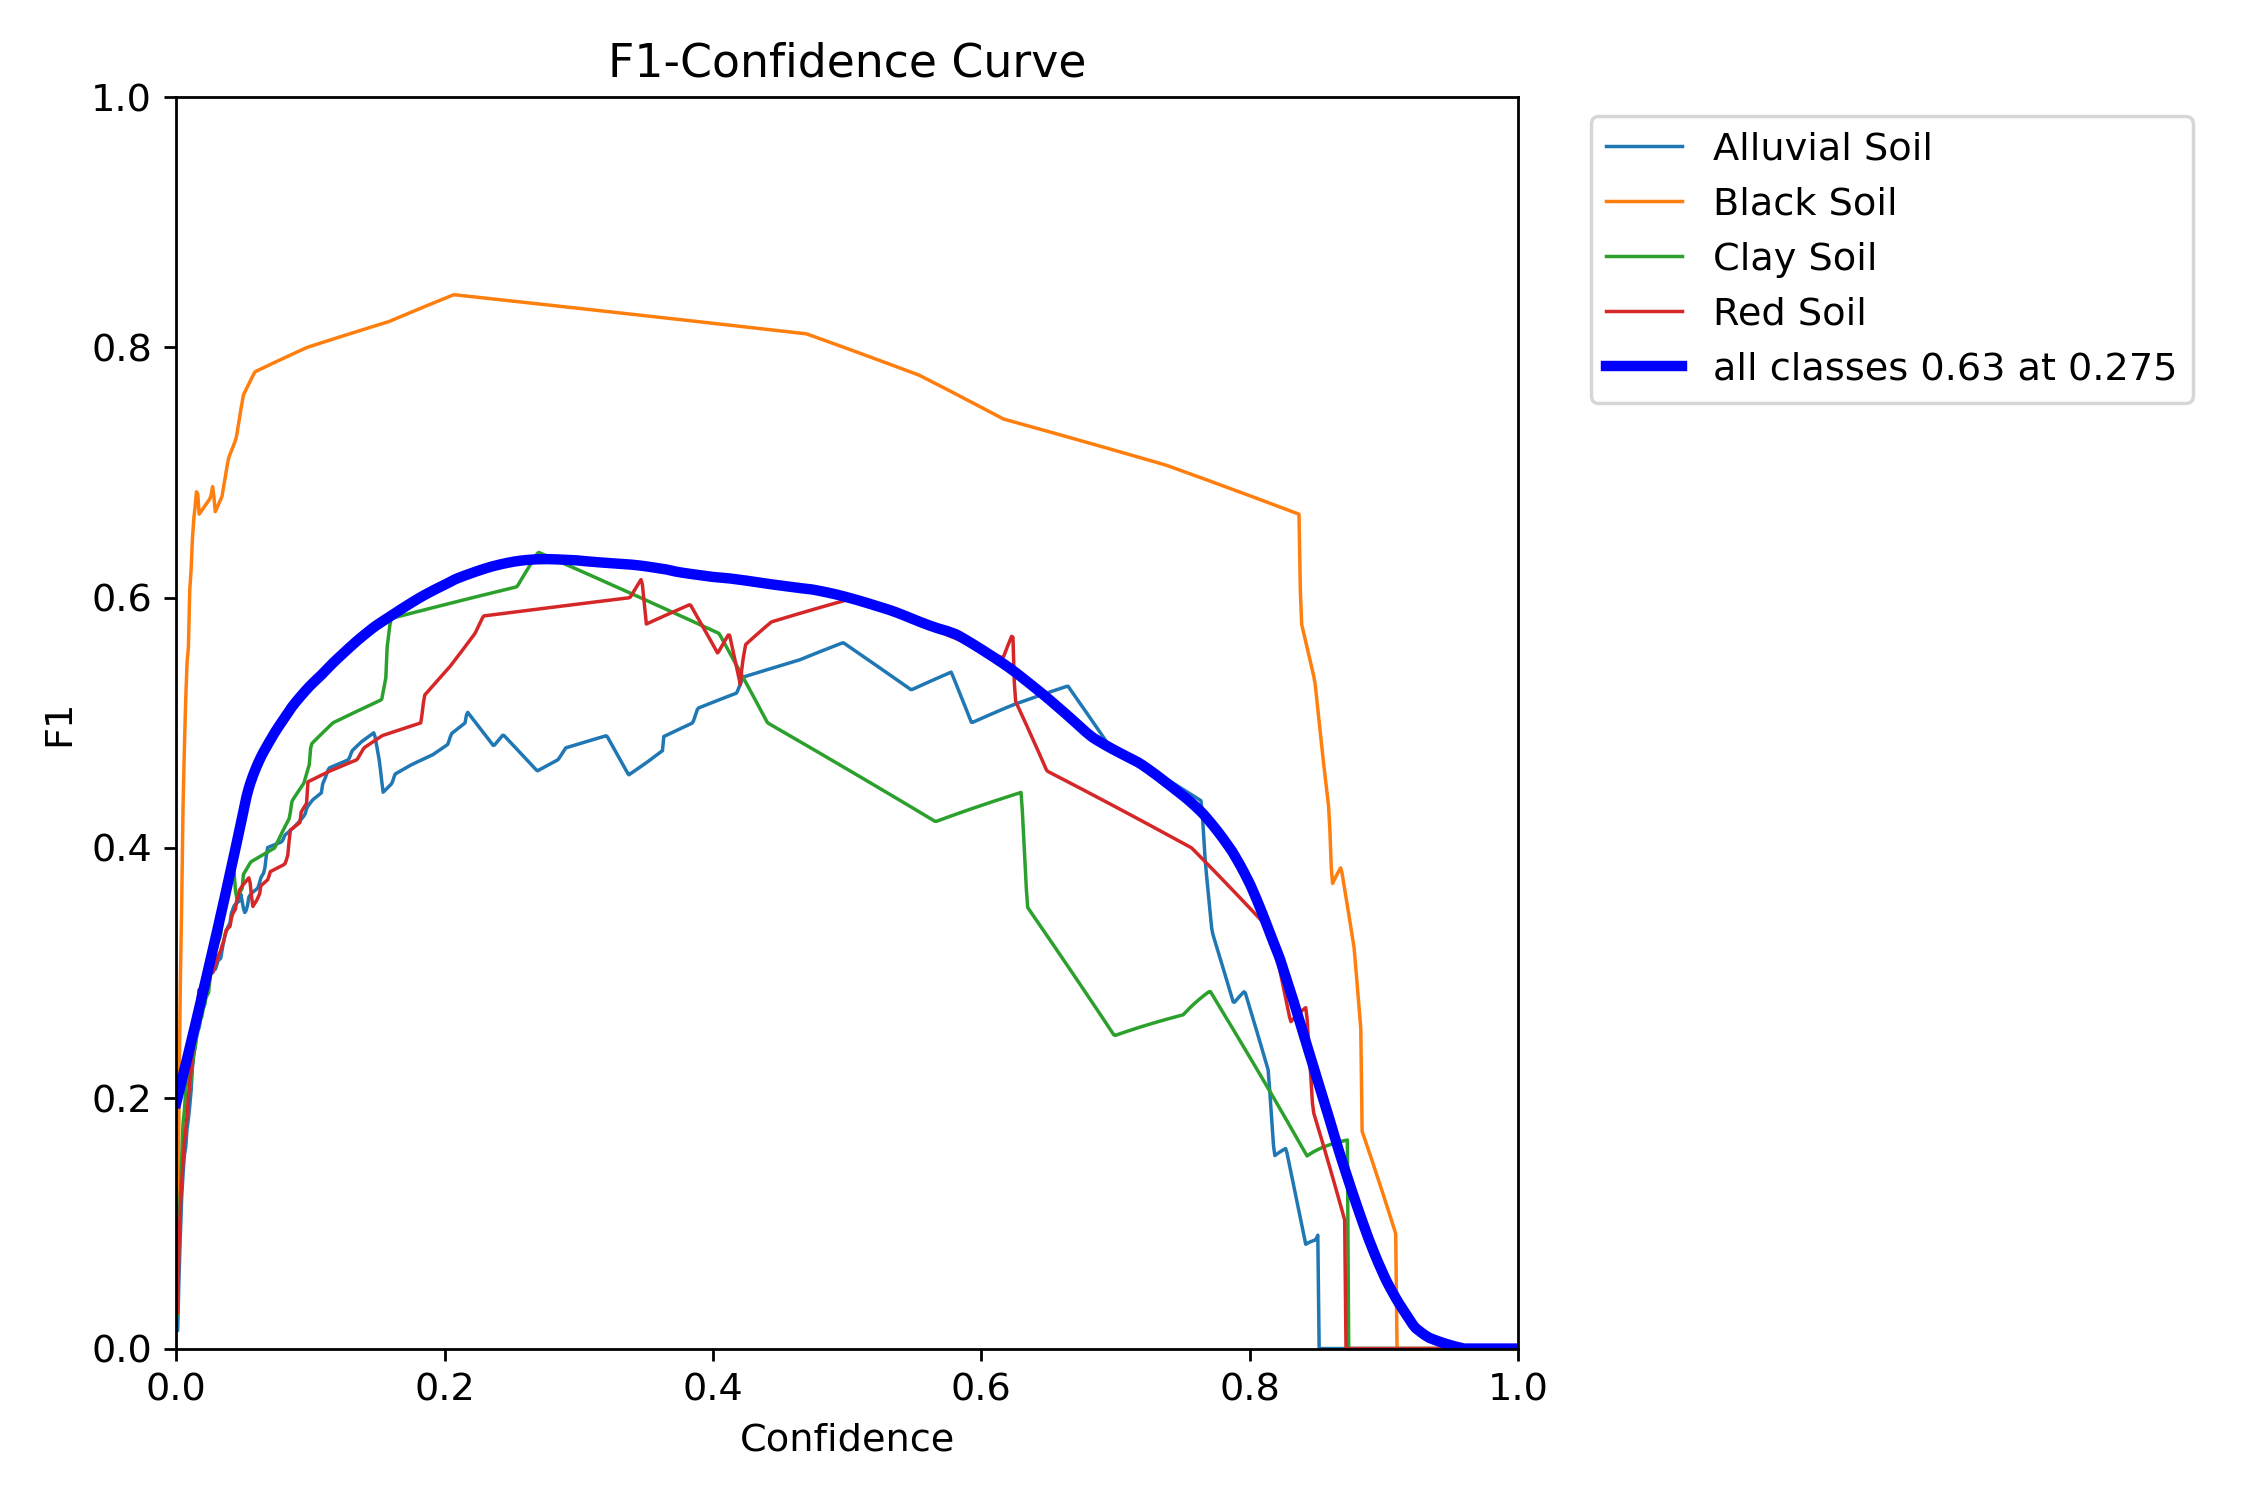

In [15]:
from IPython.display import Image, display
Image(filename=f'{resultData}/BoxF1_curve.png')